Dataset shape: (100, 18)
   clip_id                              source  \
0      0.4  youtube, 3D engine-rendered scenes   
1      0.5  youtube, 3D engine-rendered scenes   
2    231.4  youtube, 3D engine-rendered scenes   
3    233.2  youtube, 3D engine-rendered scenes   
4    864.3  youtube, 3D engine-rendered scenes   

                                     video_url     video_id  width  height  \
0  https://www.youtube.com/watch?v=AG2NSO20zkI  AG2NSO20zkI   1280     720   
1  https://www.youtube.com/watch?v=AG2NSO20zkI  AG2NSO20zkI   1280     720   
2  https://www.youtube.com/watch?v=-iYMXRQCqCw  -iYMXRQCqCw   1280     720   
3  https://www.youtube.com/watch?v=ViZdX5E3mRA  ViZdX5E3mRA   1280     720   
4  https://www.youtube.com/watch?v=5I2SnLsGWhY  5I2SnLsGWhY   1280     720   

     fps  seconds                         timestamp  frame_number  \
0  30.00   80.833  ['00:06:21.300', '00:07:42.133']          2425   
1  30.00   79.267  ['00:07:42.133', '00:09:01.400']          2378  

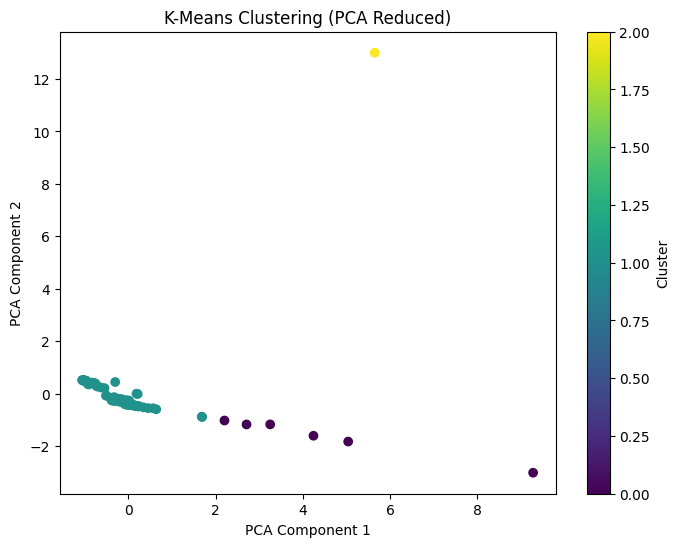

                               source  cluster
0  youtube, 3D engine-rendered scenes        1
1  youtube, 3D engine-rendered scenes        1
2  youtube, 3D engine-rendered scenes        1
3  youtube, 3D engine-rendered scenes        1
4  youtube, 3D engine-rendered scenes        1
5  youtube, 3D engine-rendered scenes        1
6  youtube, 3D engine-rendered scenes        1
7  youtube, 3D engine-rendered scenes        1
8  youtube, 3D engine-rendered scenes        1
9  youtube, 3D engine-rendered scenes        1


In [3]:
# =========================
# Step 1: Import libraries
# =========================
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# =========================
# Step 2: Load dataset
# =========================
df = pd.read_csv("miradata_v1_100_samples.csv")

print("Dataset shape:", df.shape)
print(df.head())

# =========================
# Step 3: Detect text columns (future-proof)
# =========================
text_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()

if len(text_columns) == 0:
    raise ValueError("No text column found in dataset!")

text_column = text_columns[0]
print("Using text column:", text_column)

# =========================
# Step 4: Detect numeric columns
# =========================
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Numeric columns:", numeric_columns)

# =========================
# Step 5: TF-IDF vectorization
# =========================
tfidf = TfidfVectorizer(stop_words="english", max_features=50)

text_features = tfidf.fit_transform(df[text_column].astype(str)).toarray()

# =========================
# Step 6: Scale numeric features safely
# =========================
scaler = StandardScaler()

if len(numeric_columns) > 0:
    numeric_features = scaler.fit_transform(df[numeric_columns])
else:
    numeric_features = np.zeros((len(df), 0))

# =========================
# Step 7: Combine features
# =========================
X = np.hstack((numeric_features, text_features))

print("Final feature shape:", X.shape)

# =========================
# Step 8: K-Means clustering
# =========================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

# =========================
# Step 9: PCA visualization
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], cmap="viridis")
plt.title("K-Means Clustering (PCA Reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

# =========================
# Step 10: View results
# =========================
print(df[[text_column, "cluster"]].head(10))